# Results

## Librairies

In [58]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Get results

In [59]:
results_folder = "."
file_name = "results_0_1000_nlp.csv"

In [60]:
results_df = pd.read_csv(file_name, header=None)
results_df.columns = ['error_1', 'error_2', 'error_3', 'error_polytope']

In [61]:
results_df

,error_1,error_2,error_3,error_polytope
0,0.000061,0.000061,0.000061,1.241690
1,0.008111,0.008111,0.008111,1.214943
2,0.001589,0.001589,0.001589,1.239755
3,0.000455,0.000455,0.000455,1.235694
4,0.008147,0.008147,0.008147,1.255490
...,...,...,...,...
995,0.000032,0.000032,0.000032,1.239975
996,0.001140,0.001140,0.001140,1.211014
997,0.000002,0.000002,0.000002,0.000002
998,0.054163,0.054163,0.054163,0.719523


In [62]:
results_df.shape

(1000, 4)

In [63]:
# sanity check
tolerance = 1e-6

mask_1 = ((results_df['error_1'] - results_df['error_2']).abs() < tolerance).all()
mask_2 = ((results_df['error_2'] - results_df['error_3']).abs() < tolerance).all()
mask_3 = ((results_df['error_3'] - results_df['error_1']).abs() < tolerance).all()

mask = (mask_1 and mask_2 and mask_3).item()

mask

True

## Results

In [109]:
errors_samples = results_df['error_1']
errors_polytopes = results_df['error_polytope']

In [110]:
max_samples = np.max(errors_samples)
max_polytopes = np.max(errors_polytopes)

max_samples, max_polytopes

(np.float64(1.82646358), np.float64(1.26592774588899))

#### Problematic samples

In [111]:
mask_pb = errors_samples >= errors_polytopes
indices_pb = mask_pb[mask_pb].index

print(f"There are {len(indices_pb)} problematic samples at indices:")
indices_pb

There are 50 problematic samples at indices:


Index([ 45,  68, 128, 141, 149, 151, 162, 188, 216, 233, 241, 262, 290, 296,
       320, 435, 449, 469, 495, 500, 543, 565, 576, 582, 590, 591, 621, 636,
       648, 651, 657, 659, 686, 694, 747, 753, 780, 792, 799, 819, 822, 844,
       847, 849, 883, 912, 938, 944, 961, 982],
      dtype='int64')

In [112]:
results_pb_df = results_df.loc[indices_pb]
results_pb_df.head()

,error_1,error_2,error_3,error_polytope
45,4.086790e-03,4.086790e-03,4.086790e-03,4.086786e-03
68,6.100000e-07,6.100000e-07,6.100000e-07,6.095756e-07
128,5.821520e-03,5.821520e-03,5.821520e-03,5.821517e-03
141,7.000000e-08,7.000000e-08,7.000000e-08,6.668863e-08
149,1.296875e+00,1.296875e+00,1.296875e+00,1.180835e+00


**Same sample and polytope errors**

- In these cases, the solver fail to converge and keeps the original solution as the optimal one

In [113]:
# sanity check
tol_1 = 1e-6

mask_pb_1 = ((results_pb_df['error_1'] - results_pb_df['error_polytope']).abs() < tol_1)
indices_pb_1 = mask_pb_1[mask_pb_1].index

print(f"There are {len(indices_pb_1)}/{len(indices_pb)} problematic samples for which the solver failed to converge.")
print(f"In these cases, the sample and polytope errors are the same (up to tolerance {tol_1}):")

indices_pb_1

There are 37/50 problematic samples for which the solver failed to converge.
In these cases, the sample and polytope errors are the same (up to tolerance 1e-06):


Index([ 45,  68, 128, 141, 162, 188, 216, 262, 296, 469, 500, 565, 576, 582,
       590, 621, 636, 648, 651, 657, 686, 694, 747, 753, 780, 792, 799, 819,
       822, 847, 849, 883, 912, 938, 944, 961, 982],
      dtype='int64')

In [114]:
results_pb_1_df = results_df.loc[indices_pb_1]
results_pb_1_df.head()

,error_1,error_2,error_3,error_polytope
45,4.086790e-03,4.086790e-03,4.086790e-03,4.086786e-03
68,6.100000e-07,6.100000e-07,6.100000e-07,6.095756e-07
128,5.821520e-03,5.821520e-03,5.821520e-03,5.821517e-03
141,7.000000e-08,7.000000e-08,7.000000e-08,6.668863e-08
162,2.000000e-08,2.000000e-08,2.000000e-08,1.816041e-08


**Large sample errors**

In [119]:
# sanity check
tol_2 = 1e-6

mask_pb_2 = ~mask_pb_1
indices_pb_2 = mask_pb_2[mask_pb_2].index

print(f"There are {len(indices_pb_2)}/{len(indices_pb)} problematic samples for which ???")
print(f"In these cases, the polytope errors are larger than the sample errors:")

indices_pb_2

There are 13/50 problematic samples for which ???
In these cases, the polytope errors are larger than the sample errors:


Index([149, 151, 233, 241, 290, 320, 435, 449, 495, 543, 591, 659, 844], dtype='int64')

In [120]:
results_pb_2_df = results_df.loc[indices_pb_2]
results_pb_2_df

,error_1,error_2,error_3,error_polytope
149,1.296875,1.296875,1.296875,1.180835
151,1.441312,1.441312,1.441312,1.167411
233,1.349473,1.349473,1.349473,1.158280
241,1.155084,1.155084,1.155084,1.103878
290,1.351510,1.351510,1.351510,1.037643
320,1.173953,1.173953,1.173953,1.165836
435,1.244963,1.244963,1.244963,1.191411
449,0.663689,0.663689,0.663689,0.610948
495,1.486162,1.486162,1.486162,1.176494
543,1.446208,1.446208,1.446208,1.227316


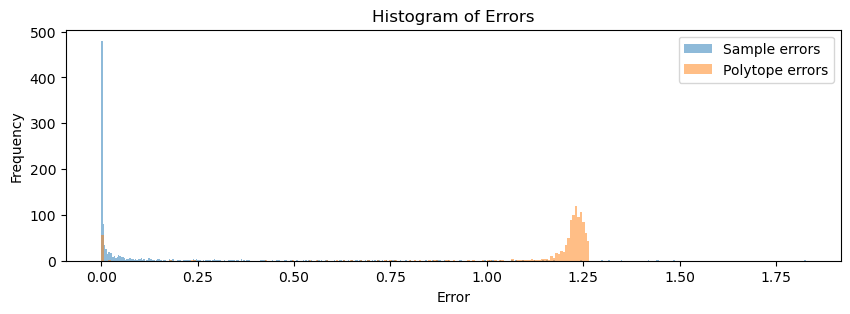

In [68]:
plt.figure(figsize=(10,3))
plt.hist(results_df['error_1'], bins=500, alpha=0.5, label='Sample errors')
plt.hist(results_df['error_polytope'], bins=200, alpha=0.5, label='Polytope errors')

plt.xlabel('Error')
plt.ylabel('Frequency')
plt.title('Histogram of Errors')
plt.legend()
# plt.grid(True)
plt.show()
